In [20]:
# 2026-03-23: first mandatory cmlykke kladde
# We have a regression problem and a classification problem.
# this project is focues on the classification problem.

# Classification problem:

#We assume that cars from different regions will have different
# characteristics, therefore we want to ask the question:

#Can we predict the origin of a car based on its the
# following attributes: acceleration, weight, horsepower,
# displacement, cylinders, MPG.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:
# Load data
df = pd.read_csv('../../data/cars.csv')
df.head()
#print(df.count())


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
# Data exploration and cleaning
# Check for missing values
#print(df.isnull().sum())

# Horsepower has '?' as missing values
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df = df.dropna(subset=['horsepower'])
print(df.count())


mpg             392
cylinders       392
displacement    392
horsepower      392
weight          392
acceleration    392
model year      392
origin          392
car name        392
dtype: int64


In [5]:
# Define features and target
features = ['acceleration', 'weight', 'horsepower', 'displacement', 'cylinders', 'mpg']
X = df[features]
y = df['origin']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# take a look at the split data:
print(X_train.count())
print(X_test.count())
print(y_train.count())
print(y_test.count())

acceleration    313
weight          313
horsepower      313
displacement    313
cylinders       313
mpg             313
dtype: int64
acceleration    79
weight          79
horsepower      79
displacement    79
cylinders       79
mpg             79
dtype: int64
313
79


In [7]:
# Single Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.7848101265822784

Classification Report:
               precision    recall  f1-score   support

           1       0.82      0.93      0.87        43
           2       0.73      0.55      0.63        20
           3       0.73      0.69      0.71        16

    accuracy                           0.78        79
   macro avg       0.76      0.72      0.74        79
weighted avg       0.78      0.78      0.78        79



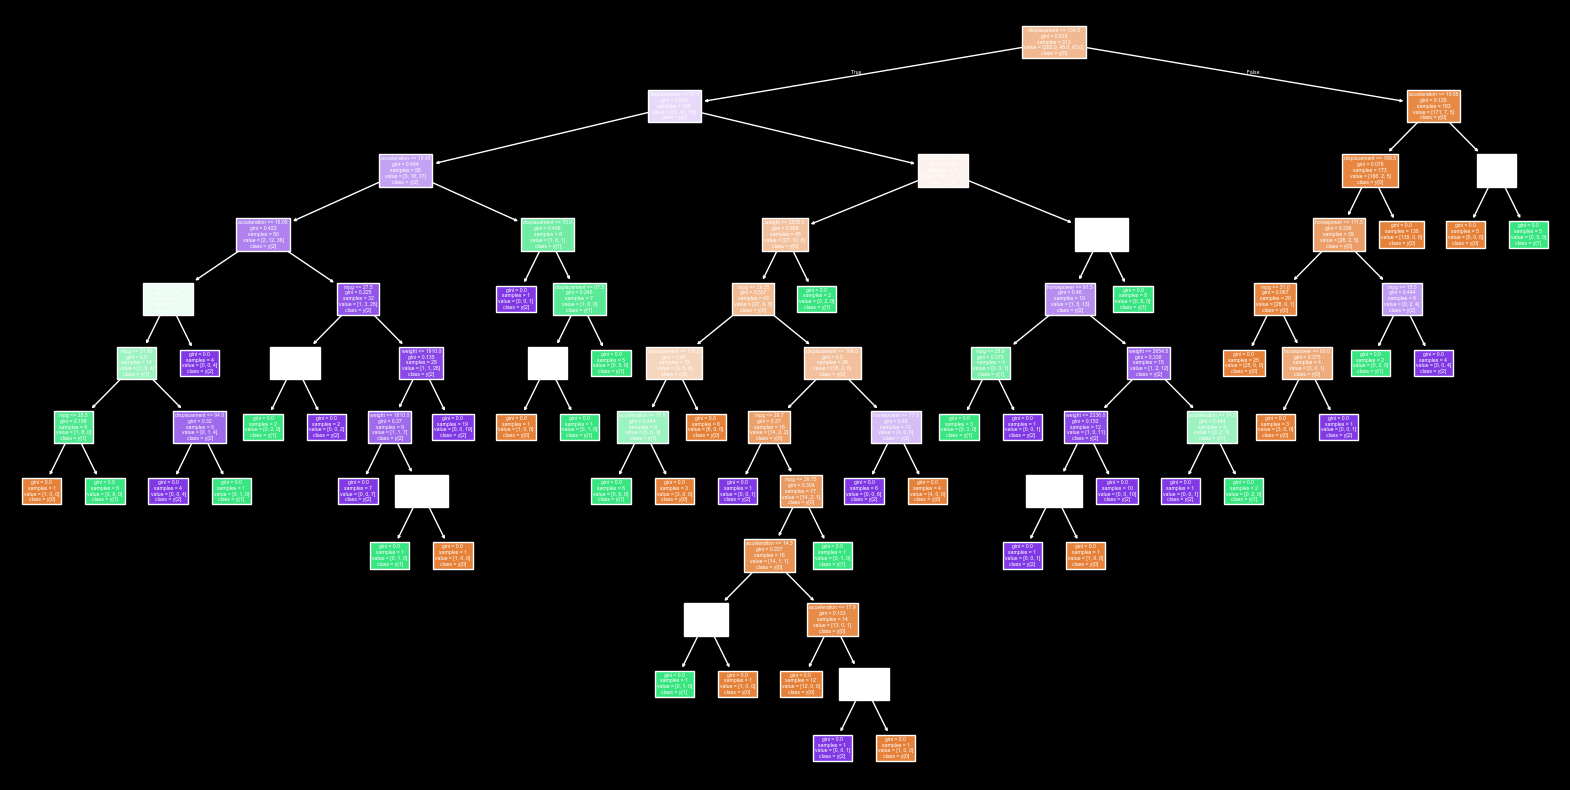

In [8]:
# Visualize Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt_model, feature_names=features, class_names=True, filled=True)
plt.show()


In [9]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.759493670886076

Classification Report:
               precision    recall  f1-score   support

           1       0.83      0.91      0.87        43
           2       0.62      0.65      0.63        20
           3       0.73      0.50      0.59        16

    accuracy                           0.76        79
   macro avg       0.73      0.69      0.70        79
weighted avg       0.76      0.76      0.75        79



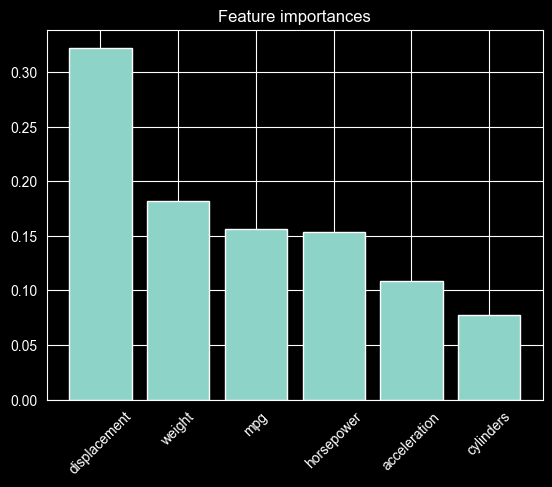

In [10]:
# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.title("Feature importances")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.show()


In [11]:
# feature importance asa a table:
# Create a DataFrame with features and their importance scores
importance_table = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
})

# Sort by importance (descending)
importance_table = importance_table.sort_values(by='Importance', ascending=False)

print(importance_table)

        Feature  Importance
3  displacement    0.322400
1        weight    0.181861
5           mpg    0.156178
2    horsepower    0.153274
0  acceleration    0.108909
4     cylinders    0.077378
